# Week 4: Vector Power-Up & Raster Integration

**Student Worksheet** — Fill in the code cells using AI assistance or your own code.

This week you will:
1. Master vector aggregation (dissolve & groupby)
2. Understand raster data as NumPy arrays with spatial metadata
3. Compute terrain slope from DEM
4. Extract raster values into vector shapes (zonal statistics)

**Packages needed:** `geopandas`, `rioxarray`, `rasterstats`, `numpy`, `matplotlib`

> If you haven't installed them yet, run:  
> `pip install rioxarray rasterstats geopandas folium mapclassify matplotlib`

## Cell [1] — Environment Setup

Import all necessary packages and load Week 3 township data.

In [8]:
# Import required libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rioxarray as rxr
import xarray as xr
from urllib.parse import quote

# TGOS URL setup
# TGOS_BASE = 'https://services4.arcgis.com/nkvliNhC38k4WmFn/ArcGIS/rest/services/%E9%84%89(%E9%8E%AE%E3%80%81%E5%B8%82%E3%80%81%E5%8D%80)%E7%95%8C%E7%B7%9A1140318%E5%BC%B5%E9%80%B2%E7%9B%8821021/FeatureServer'
# url = TGOS_BASE + quote('鄉(鎮、市、區)界線1140318.zip')

# Load TGOS townships
#townships = gpd.read_file(url, layer='TOWN_MOI_1140318')
townships = gpd.read_file(r"data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp")

# Convert to EPSG:3826
townships = townships.to_crs('EPSG:3826')

# Print shape and CRS
print(f"Shape: {townships.shape}")
print(f"CRS: {townships.crs}")
print("\nFirst 5 rows:")
print(townships.head())

Shape: (368, 8)
CRS: EPSG:3826

First 5 rows:
  TOWNID  TOWNCODE COUNTYNAME TOWNNAME             TOWNENG COUNTYID  \
0    V02  10014020        臺東縣      成功鎮  Chenggong Township        V   
1    T21  10013210        屏東縣      佳冬鄉    Jiadong Township        T   
2    P13  10009130        雲林縣      麥寮鄉    Mailiao Township        P   
3    V11  10014110        臺東縣      綠島鄉      Lüdao Township        V   
4    V16  10014160        臺東縣      蘭嶼鄉      Lanyu Township        V   

  COUNTYCODE                                           geometry  
0      10014  POLYGON ((286994.568 2569686.978, 287066.318 2...  
1      10013  POLYGON ((203528.677 2484633.419, 203536.121 2...  
2      10009  POLYGON ((178880.906 2634847.772, 178880.637 2...  
3      10014  MULTIPOLYGON (((300508.457 2508651.739, 300539...  
4      10014  MULTIPOLYGON (((313194.739 2427361.112, 313146...  


## Cell [2] — Dissolve & Groupby

**Dissolve**: Merge 368 townships → ~22 counties  
**Groupby**: Count shelters per county and sum capacity

In [9]:
# 1. Dissolve townships by 'COUNTYNAME' → counties GeoDataFrame
counties = townships.dissolve(by='COUNTYNAME')

# 2. Print: how many counties? What geometry types?
print(f"Number of counties: {len(counties)}")
print(f"Geometry types: {counties.geometry.type.unique()}")

# 3. Calculate area in km² for each county
# Convert area from square meters to square kilometers
counties['area_km2'] = counties.geometry.area / 1_000_000

# 4. Show the top 5 largest counties
print("\nTop 5 largest counties by area:")
top5_counties = counties.nlargest(5, 'area_km2')[['area_km2']]
print(top5_counties)

Number of counties: 22
Geometry types: <StringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str

Top 5 largest counties by area:
               area_km2
COUNTYNAME             
花蓮縣         4605.284306
南投縣         4097.729914
臺東縣         3582.210917
高雄市         2998.488305
屏東縣         2805.036755


---

## 🔬 Lab 1: Vector Aggregation (20 minutes)

**Goal**: Practice dissolve & groupby before entering the raster world.

> **⚠️ 注意**：Lab 1 使用**合成資料**（synthetic data）練習 dissolve/groupby 操作。課後作業（ARIA v2.0）會使用**真實的避難收容所 CSV**，操作方式相同但資料來源不同。

### Step 1: Dissolve townships → counties

In [10]:
# Dissolve all townships into counties using COUNTYNAME
counties_lab = townships.dissolve(by='COUNTYNAME')

# Filter for Hualien County (花蓮縣) and check its geometry type and area
hualien_county = counties_lab[counties_lab.index == '花蓮縣']

if len(hualien_county) > 0:
    hualien = hualien_county.iloc[0]
    print(f"Hualien County (花蓮縣):")
    print(f"Geometry type: {hualien.geometry.type}")
    print(f"Area: {hualien.geometry.area / 1_000_000:.2f} km²")
else:
    print("Hualien County not found in the data")

Hualien County (花蓮縣):
Geometry type: Polygon
Area: 4605.28 km²


C:\Users\詹文慧\AppData\Local\Temp\ipykernel_16732\454226563.py:10: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  print(f"Geometry type: {hualien.geometry.type}")


### Step 2: Create synthetic shelter data for Hualien

In [11]:
# Filter townships for Hualien County towns
hualien_towns = townships[townships['COUNTYNAME'] == '花蓮縣'].copy()

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic shelter data
shelters_data = []
shelter_id = 1

for idx, town in hualien_towns.iterrows():
    # Generate 2-8 shelters per town
    num_shelters = np.random.randint(2, 9)
    
    for _ in range(num_shelters):
        # Random capacity between 50-500
        capacity = np.random.randint(50, 501)
        
        # Use town centroid as shelter location
        shelter_geom = town.geometry.centroid
        
        shelters_data.append({
            'shelter_id': f'S{shelter_id:03d}',
            'TOWNNAME': town['TOWNNAME'],
            'capacity': capacity,
            'geometry': shelter_geom
        })
        
        shelter_id += 1

# Create GeoDataFrame
shelters_gdf = gpd.GeoDataFrame(shelters_data, crs='EPSG:3826')

print(f"Created {len(shelters_gdf)} shelters in {len(hualien_towns)} towns")
print("\nFirst 5 shelters:")
print(shelters_gdf.head())
print(f"\nShelters per town:")
print(shelters_gdf.groupby('TOWNNAME').size())

Created 60 shelters in 13 towns

First 5 shelters:
  shelter_id TOWNNAME  capacity                        geometry
0       S001      光復鄉       485  POINT (294406.293 2615944.762)
1       S002      光復鄉       398  POINT (294406.293 2615944.762)
2       S003      光復鄉       320  POINT (294406.293 2615944.762)
3       S004      光復鄉       156  POINT (294406.293 2615944.762)
4       S005      光復鄉       121  POINT (294406.293 2615944.762)

Shelters per town:
TOWNNAME
光復鄉    8
卓溪鄉    8
吉安鄉    3
壽豐鄉    3
富里鄉    6
新城鄉    3
玉里鎮    6
瑞穗鄉    3
秀林鄉    2
花蓮市    8
萬榮鄉    5
豐濱鄉    2
鳳林鎮    3
dtype: int64


### Step 3: Groupby — Statistics per town

In [12]:
# Group shelters by TOWNNAME
town_summary = shelters_gdf.groupby('TOWNNAME').agg(
    shelter_count=('capacity', 'size'),
    total_capacity=('capacity', 'sum'),
    avg_capacity=('capacity', 'mean')
).round(1)

# Sort by total_capacity descending
town_summary = town_summary.sort_values('total_capacity', ascending=False)

print("Shelter statistics by town (sorted by total capacity):")
print(town_summary)

Shelter statistics by town (sorted by total capacity):
          shelter_count  total_capacity  avg_capacity
TOWNNAME                                             
卓溪鄉                   8            2363         295.4
花蓮市                   8            1990         248.8
光復鄉                   8            1940         242.5
萬榮鄉                   5            1609         321.8
富里鄉                   6            1496         249.3
玉里鎮                   6            1341         223.5
吉安鄉                   3            1199         399.7
壽豐鄉                   3            1060         353.3
鳳林鎮                   3             946         315.3
新城鄉                   3             811         270.3
瑞穗鄉                   3             781         260.3
豐濱鄉                   2             536         268.0
秀林鄉                   2             434         217.0


### Step 4: Merge stats back to geometry & visualize

In [13]:
# Create outputs directory if it doesn't exist
import os
os.makedirs('outputs', exist_ok=True)

# Merge the groupby statistics back to the Hualien township geometry
hualien_towns_with_stats = hualien_towns.merge(
    town_summary, 
    left_on='TOWNNAME', 
    right_index=True,
    how='left'
)

# Fill NaN values with 0 for towns with no shelters
hualien_towns_with_stats = hualien_towns_with_stats.fillna({
    'shelter_count': 0,
    'total_capacity': 0,
    'avg_capacity': 0
})

# Convert to EPSG:4326 for .explore()
hualien_towns_4326 = hualien_towns_with_stats.to_crs('EPSG:4326')

# Create interactive map with .explore()
m = hualien_towns_4326.explore(
    column='total_capacity',
    cmap='YlOrRd',
    tooltip=['TOWNNAME', 'shelter_count', 'total_capacity'],
    popup=True,
    legend=True,
    legend_kwds={
        'caption': 'Total Shelter Capacity',
        'loc': 'upper left'
    },
    style_kwds={
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.7
    }
)

# Save the map as HTML
m.save('outputs/lab1_hualien_capacity.html')

print("Map saved to 'outputs/lab1_hualien_capacity.html'")
print(f"Towns with shelter data: {len(hualien_towns_with_stats)}")
print("\nMerged data sample:")
print(hualien_towns_with_stats[['TOWNNAME', 'shelter_count', 'total_capacity', 'avg_capacity']].head())

Map saved to 'outputs/lab1_hualien_capacity.html'
Towns with shelter data: 13

Merged data sample:
    TOWNNAME  shelter_count  total_capacity  avg_capacity
140      光復鄉              8            1940         242.5
141      瑞穗鄉              3             781         260.3
142      富里鄉              6            1496         249.3
180      吉安鄉              3            1199         399.7
181      壽豐鄉              3            1060         353.3


---

## Cell [3] — The Raster Glass Box: It's Just a Matrix

A raster (like a DEM) is a **NumPy array with a GPS**. Each pixel = one numeric value.

In [14]:
# Create a synthetic 100x80 DEM with valley profile
import numpy as np

# Set dimensions
height, width = 80, 100

# Create normalized coordinate grids (0-1)
x = np.linspace(0, 1, width)
y = np.linspace(0, 1, height)
X, Y = np.meshgrid(x, y)

# Elevation formula: valley profile (low center, high sides)
elevation = 50 + 800*(2*X-1)**2 + 200*Y + 30*np.sin(8*X)*np.cos(6*Y)

# Set bounds for EPSG:3826
x_bounds = [302000, 303600]  # 1.6km width
y_bounds = [2638000, 2640000]  # 2km height

# Create xarray DataArray with spatial metadata
dem_synth = xr.DataArray(
    elevation[np.newaxis, :, :],  # Add band dimension
    coords={
        'band': [1],
        'y': np.linspace(y_bounds[1], y_bounds[0], height),  # y decreases
        'x': np.linspace(x_bounds[0], x_bounds[1], width)
    },
    dims=['band', 'y', 'x']
)

# Set CRS and spatial reference
dem_synth.rio.set_crs('EPSG:3826')
dem_synth.rio.write_transform()

# Print information
print(f"Shape: {dem_synth.shape}")
print(f"CRS: {dem_synth.rio.crs}")
print(f"Resolution: {dem_synth.rio.resolution()}")  # (pixel_width, pixel_height)
print(f"Elevation range: {dem_synth.min().values:.1f} to {dem_synth.max().values:.1f} m")
print(f"Top-left 5x5 pixel values:")
print(dem_synth[0, :5, :5].values)

Shape: (1, 80, 100)
CRS: EPSG:3826
Resolution: (16.161616161616163, -25.31645569620253)
Elevation range: 25.8 to 1078.5 m
Top-left 5x5 pixel values:
[[850.         820.4248699  791.48693004 763.17047923 735.46002188]
 [852.53164557 822.94953454 794.00465932 765.68136397 737.96419758]
 [855.06329114 825.46027759 796.49463627 768.15084676 740.41359191]
 [857.59493671 827.95721956 798.95710112 770.579286   742.8086791 ]
 [860.12658228 830.44056053 801.39245275 772.96727673 745.15024649]]


C:\Users\詹文慧\AppData\Local\Temp\ipykernel_16732\3037849119.py:31: FutureWarning: It is recommended to use 'rio.write_crs()' instead. 'rio.set_crs()' will likelybe removed in a future release.
  dem_synth.rio.set_crs('EPSG:3826')


## Cell [4] — Affine Transform

How does `Matrix[row, col]` become real-world `(X, Y)` coordinates?

In [15]:
# Get the affine transform from DEM
transform = dem_synth.rio.transform()

# Print the 6 parameters with labels
print("Affine Transform Parameters:")
print(f"a (pixel width): {transform.a:.2f} m")
print(f"b (rotation X): {transform.b:.2f}")
print(f"c (top-left X): {transform.c:.2f} m")
print(f"d (rotation Y): {transform.d:.2f}")
print(f"e (pixel height): {transform.e:.2f} m")
print(f"f (top-left Y): {transform.f:.2f} m")

# Manually convert pixel [5, 10] to real-world coordinates
row, col = 5, 10
real_x = transform.a * col + transform.b * row + transform.c
real_y = transform.d * col + transform.e * row + transform.f

print(f"\nPixel [{row}, {col}] → Real-world coordinates:")
print(f"X: {real_x:.2f} m")
print(f"Y: {real_y:.2f} m")

# Get elevation value at that pixel
elevation_value = dem_synth[0, row, col].values
print(f"Elevation at pixel [{row}, {col}]: {elevation_value:.1f} m")

# Verify with rioxarray's built-in method
x_coords = dem_synth.x[col].values
y_coords = dem_synth.y[row].values
print(f"\nVerification from coordinates:")
print(f"X from array: {x_coords:.2f} m")
print(f"Y from array: {y_coords:.2f} m")

Affine Transform Parameters:
a (pixel width): 16.16 m
b (rotation X): 0.00
c (top-left X): 301991.92 m
d (rotation Y): 0.00
e (pixel height): -25.32 m
f (top-left Y): 2640012.66 m

Pixel [5, 10] → Real-world coordinates:
X: 302153.54 m
Y: 2639886.08 m
Elevation at pixel [5, 10]: 592.2 m

Verification from coordinates:
X from array: 302161.62 m
Y from array: 2639873.42 m


## Cell [5] — DEM Visualization

Create a side-by-side plot: elevation + hillshade.

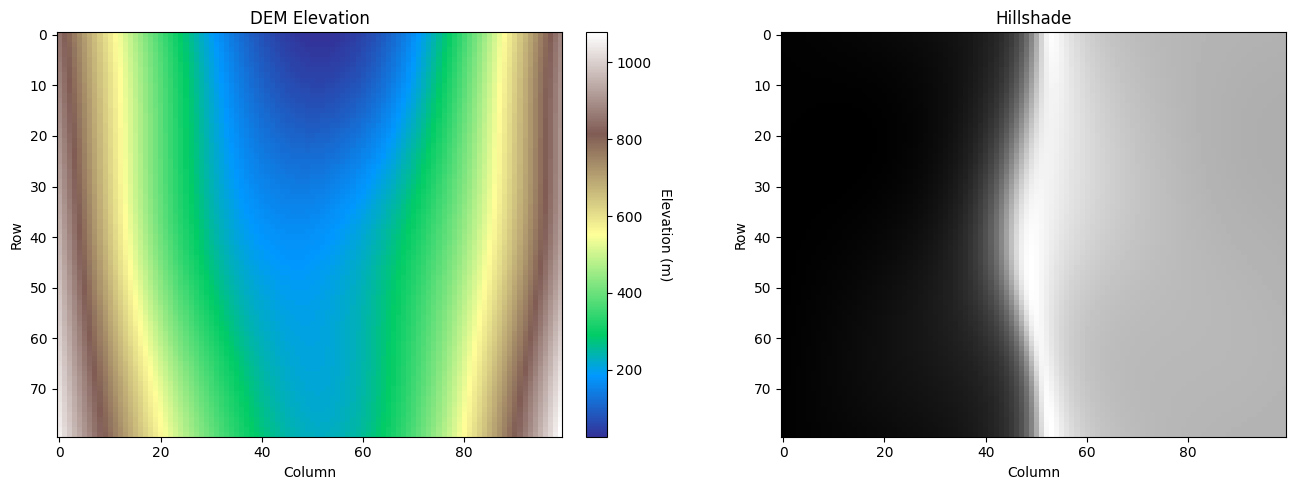

DEM visualization saved as 'outputs/cell5_dem.png'
Elevation range: 25.8 to 1078.5 m


In [17]:
# Create a 1x2 subplot: elevation + hillshade
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Extract elevation as numpy array for hillshade
elevation_array = dem_synth[0].values

# Left: Elevation with terrain colormap
elevation_plot = ax1.imshow(
    elevation_array, 
    cmap='terrain', 
    origin='upper'
)
ax1.set_title('DEM Elevation')
ax1.set_xlabel('Column')
ax1.set_ylabel('Row')

# Add colorbar for elevation
cbar1 = plt.colorbar(elevation_plot, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('Elevation (m)', rotation=270, labelpad=15)

# Right: Hillshade
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(elevation_array, vert_exag=10, dx=16, dy=25)

hillshade_plot = ax2.imshow(
    hillshade, 
    cmap='gray', 
    origin='upper'
)
ax2.set_title('Hillshade')
ax2.set_xlabel('Column')
ax2.set_ylabel('Row')

# Adjust layout and save
plt.tight_layout()
plt.savefig('outputs/cell5_dem.png', dpi=150, bbox_inches='tight')
plt.show()

print("DEM visualization saved as 'outputs/cell5_dem.png'")
print(f"Elevation range: {dem_synth.min().values:.1f} to {dem_synth.max().values:.1f} m")

---

## 🔬 Lab 2: Raster Exploration on Colab (15 minutes)

### ⚡ 請選擇你的環境：

| | **Option A: Google Colab（建議）** | **Option B: 本機 fallback** |
|---|---|---|
| 適用情境 | 網路正常、Drive mount 成功 | Colab 有問題或無法連線 |
| DEM 來源 | `dem_20m_hualien.tif`（Pre-lab 已下載到 Drive） | 使用 Cell [3] 的合成 DEM (`dem_synth`) |
| 後續 Step 2-4 | 用 `dem` 變數 | 用 `dem_synth` 變數（已在前面建立） |

> **Fallback 快速切換**：如果 Colab 不通，跳過 Step 1，直接到 Step 2，把 `dem` 改成 `dem_synth` 即可繼續。
> 
> **Note**: Steps 5-6 (zonal stats & risk classification) are included for reference — they will be completed in the homework.

### Step 1: Colab Setup

In [ ]:
# Lab 2 Step 1: Run in Colab!
# 1. Install packages: !pip install rioxarray rasterstats geopandas -q
# 2. Mount Google Drive
# 3. Import all packages

# AI Prompt suggestion:
# "Set up my Colab environment:
#  1. pip install rioxarray rasterstats geopandas
#  2. Mount Google Drive with drive.mount('/content/drive')
#  3. Import rioxarray, geopandas, numpy, matplotlib.pyplot, rasterstats"


### Step 2: Load DEM & Inspect

In [20]:
# Lab 2 Step 2: Load DEM & Inspect
# Option A: Load real GeoTIFF DEM (if available)
# dem = rxr.open_rasterio('path/to/your/dem.tif')

# Option B: Use the synthetic DEM we created earlier
dem = dem_synth

# Print DEM properties
print("=== DEM Properties ===")
print(f"Shape: {dem.shape}")
print(f"CRS: {dem.rio.crs}")
print(f"Transform: {dem.rio.transform()}")
print(f"Bounds: {dem.rio.bounds()}")
print(f"Elevation range: {dem.min().values:.1f} to {dem.max().values:.1f} m")

# Calculate total pixel count
total_pixels = dem.shape[1] * dem.shape[2]  # height * width
print(f"Total pixel count: {total_pixels:,}")

# Print resolution information
resolution = dem.rio.resolution()
print(f"Pixel resolution: {resolution[0]:.2f} x {abs(resolution[1]):.2f} meters")

# Print coordinate system details
print(f"\nCoordinate system: {dem.rio.crs}")
if hasattr(dem.rio.crs, 'to_epsg'):
    epsg_code = dem.rio.crs.to_epsg()
    if epsg_code:
        print(f"EPSG code: {epsg_code}")
    else:
        print("EPSG code: Not available")

=== DEM Properties ===
Shape: (1, 80, 100)
CRS: EPSG:3826
Transform: | 16.16, 0.00, 301991.92|
| 0.00,-25.32, 2640012.66|
| 0.00, 0.00, 1.00|
Bounds: (301991.9191919192, 2637987.341772152, 303608.0808080808, 2640012.658227848)
Elevation range: 25.8 to 1078.5 m
Total pixel count: 8,000
Pixel resolution: 16.16 x 25.32 meters

Coordinate system: EPSG:3826
EPSG code: 3826


### Step 3: Visualize DEM

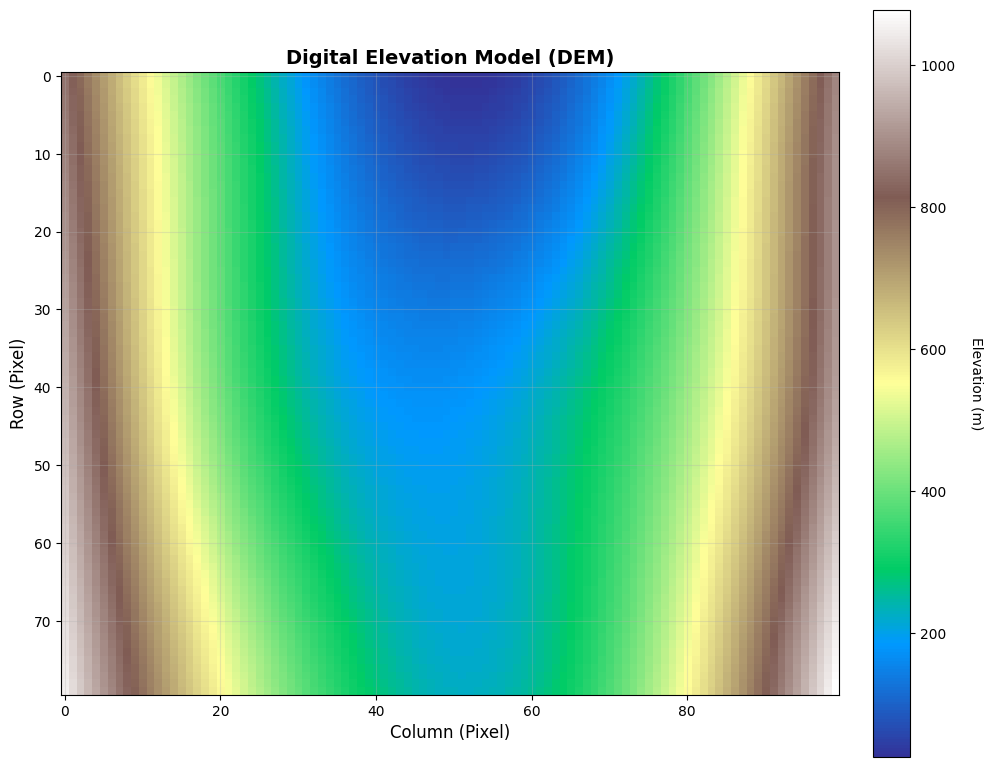

Elevation Statistics:
  Min: 25.8 m
  Max: 1078.5 m
  Mean: 421.9 m
  Std: 250.1 m


In [21]:
# Lab 2 Step 3: Visualize DEM
import matplotlib.pyplot as plt

# Create figure with specified size
plt.figure(figsize=(10, 8))

# Extract elevation data (remove band dimension)
elevation_data = dem[0].values

# Display DEM with terrain colormap
im = plt.imshow(elevation_data, cmap='terrain', origin='upper')

# Add colorbar with proper label
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Elevation (m)', rotation=270, labelpad=20)

# Set title and labels
plt.title('Digital Elevation Model (DEM)', fontsize=14, fontweight='bold')
plt.xlabel('Column (Pixel)', fontsize=12)
plt.ylabel('Row (Pixel)', fontsize=12)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Print elevation statistics
print(f"Elevation Statistics:")
print(f"  Min: {elevation_data.min():.1f} m")
print(f"  Max: {elevation_data.max():.1f} m")
print(f"  Mean: {elevation_data.mean():.1f} m")
print(f"  Std: {elevation_data.std():.1f} m")

### Step 4: Compute Slope

=== Slope Statistics ===
Min slope: 2.22°
Max slope: 59.91°
Mean slope: 36.64°
Std slope: 15.97°
Pixels > 30°: 5,237 (65.5%)


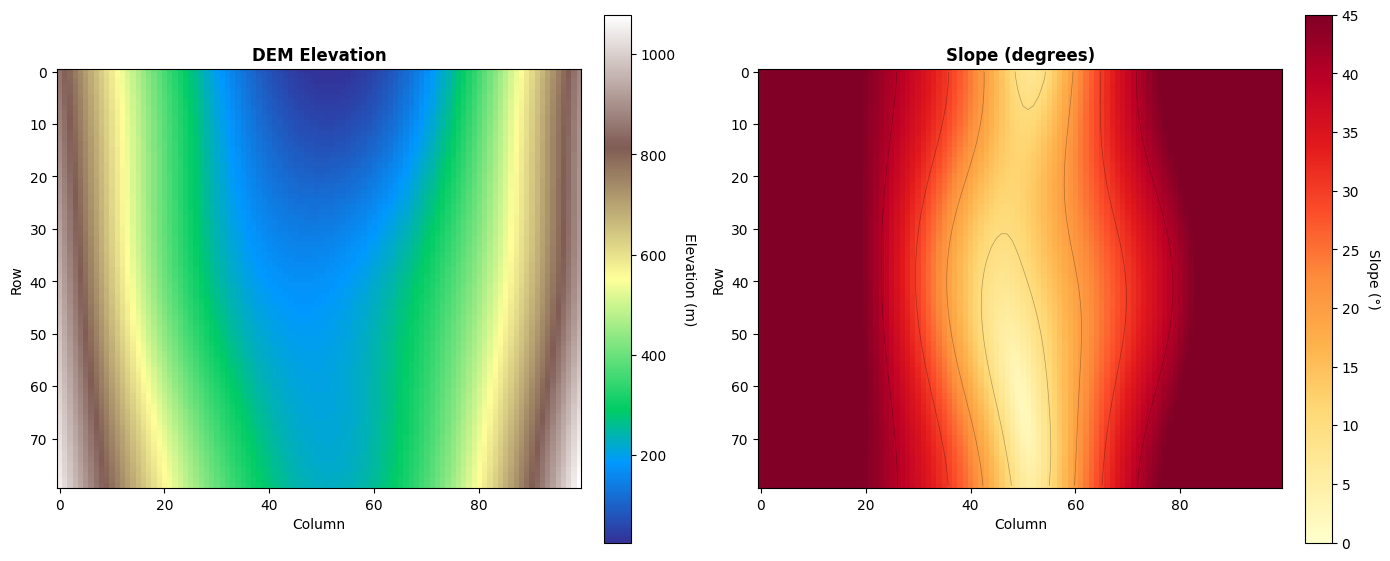


=== Slope Classification ===
Gentle (0-10°): 472 pixels (5.9%)
Moderate (10-20°): 1,189 pixels (14.9%)
Steep (20-30°): 1,102 pixels (13.8%)
Very Steep (>30°): 5,237 pixels (65.5%)


In [22]:
# Lab 2 Step 4: Compute Slope from DEM
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract 2D elevation array
elevation = dem.values[0]

# 2. Compute gradient using 20m pixel spacing
dy, dx = np.gradient(elevation, 20)

# 3. Calculate slope in degrees
slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
slope_deg = np.degrees(slope_rad)

# 4. Print slope statistics
print("=== Slope Statistics ===")
print(f"Min slope: {slope_deg.min():.2f}°")
print(f"Max slope: {slope_deg.max():.2f}°")
print(f"Mean slope: {slope_deg.mean():.2f}°")
print(f"Std slope: {slope_deg.std():.2f}°")

# Calculate percentage of pixels > 30 degrees
pixels_gt_30 = np.sum(slope_deg > 30)
total_pixels = slope_deg.size
percentage_gt_30 = (pixels_gt_30 / total_pixels) * 100

print(f"Pixels > 30°: {pixels_gt_30:,} ({percentage_gt_30:.1f}%)")

# 5. Create 1x2 subplot: elevation vs slope
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Elevation with terrain colormap
elev_im = ax1.imshow(elevation, cmap='terrain', origin='upper')
ax1.set_title('DEM Elevation', fontsize=12, fontweight='bold')
ax1.set_xlabel('Column')
ax1.set_ylabel('Row')

# Add colorbar for elevation
cbar1 = plt.colorbar(elev_im, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('Elevation (m)', rotation=270, labelpad=15)

# Right: Slope with YlOrRd colormap
slope_im = ax2.imshow(slope_deg, cmap='YlOrRd', origin='upper', vmin=0, vmax=45)
ax2.set_title('Slope (degrees)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Column')
ax2.set_ylabel('Row')

# Add colorbar for slope
cbar2 = plt.colorbar(slope_im, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Slope (°)', rotation=270, labelpad=15)

# Add contour lines for better slope visualization
ax2.contour(slope_deg, levels=[10, 20, 30, 40], colors='black', alpha=0.3, linewidths=0.5)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Additional slope classification summary
print("\n=== Slope Classification ===")
print(f"Gentle (0-10°): {np.sum(slope_deg <= 10):,} pixels ({np.sum(slope_deg <= 10)/total_pixels*100:.1f}%)")
print(f"Moderate (10-20°): {np.sum((slope_deg > 10) & (slope_deg <= 20)):,} pixels ({np.sum((slope_deg > 10) & (slope_deg <= 20))/total_pixels*100:.1f}%)")
print(f"Steep (20-30°): {np.sum((slope_deg > 20) & (slope_deg <= 30)):,} pixels ({np.sum((slope_deg > 20) & (slope_deg <= 30))/total_pixels*100:.1f}%)")
print(f"Very Steep (>30°): {np.sum(slope_deg > 30):,} pixels ({percentage_gt_30:.1f}%)")

### Step 5: Zonal Statistics

=== Shelter-DEM Analysis Workflow ===

Step 1: Verifying CRS compatibility...
DEM CRS: EPSG:3826
Shelter CRS: EPSG:3826
✅ CRS match confirmed - both are in EPSG:3826!

Step 2: Creating 200m buffers around shelters...
✅ Created 200m buffers for all 10 shelters

Step 3: Computing slope from DEM...
✅ Slope computed: 1.76° to 53.74°
   Using pixel resolution: 16.2 x 25.3 meters

Step 4: Saving temporary GeoTIFFs...
✅ DEM saved to temporary file
✅ Slope saved to temporary file

Step 5: Extracting elevation zonal statistics...
Step 6: Extracting slope zonal statistics...
✅ All zonal statistics extracted successfully

Step 7: Merging results and creating final table...
✅ Results merged successfully!

=== FINAL RESULTS TABLE ===
  shelter_id  mean_elev  min_elev  max_elev  std_elev  mean_slope  max_slope
0       S001     114.96      0.00    270.34     69.47       19.42      33.36
1       S002     372.77    212.08    599.71     98.08       31.79      43.40
2       S003     581.25      0.00    8

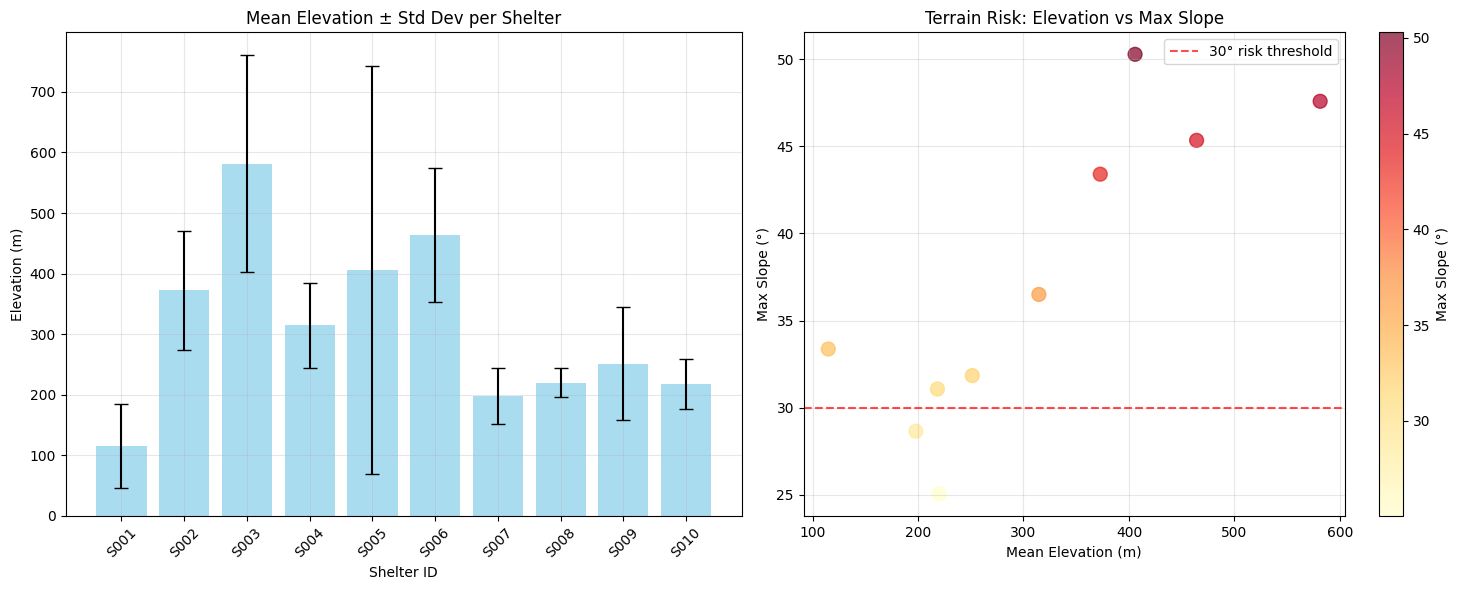

✅ Analysis complete! Visualization saved to 'outputs/shelter_dem_analysis.png'


In [34]:
# Complete Shelter-DEM Analysis Workflow
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import rioxarray as rxr
import rasterio
from rasterio.transform import from_bounds
from rasterstats import zonal_stats
import tempfile
import os
from shapely.geometry import Point
import matplotlib.pyplot as plt

print("=== Shelter-DEM Analysis Workflow ===\n")

# Step 1: Verify CRS compatibility
print("Step 1: Verifying CRS compatibility...")
print(f"DEM CRS: {dem_synth.rio.crs}")
print(f"Shelter CRS: {shelters_gdf.crs}")

if dem_synth.rio.crs == shelters_gdf.crs:
    print("✅ CRS match confirmed - both are in EPSG:3826!")
else:
    print("❌ CRS mismatch - reprojecting shelters...")
    shelters_gdf = shelters_gdf.to_crs(dem_synth.rio.crs)
    print(f"✅ Shelters reprojected to: {shelters_gdf.crs}")

# Step 2: Create 200m buffers around shelters
print("\nStep 2: Creating 200m buffers around shelters...")
shelters_gdf['buffer_200m'] = shelters_gdf.geometry.buffer(200)
print(f"✅ Created 200m buffers for all {len(shelters_gdf)} shelters")

# Step 3: Compute slope from DEM
print("\nStep 3: Computing slope from DEM...")
elevation = dem_synth.values[0]

# Get actual pixel resolution from DEM
pixel_width, pixel_height = abs(dem_synth.rio.resolution()[0]), abs(dem_synth.rio.resolution()[1])
dy, dx = np.gradient(elevation, pixel_height)  # Use actual pixel spacing
slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
slope_deg = np.degrees(slope_rad)

# Create slope xarray with same metadata as DEM
slope_xr = xr.DataArray(
    slope_deg[np.newaxis, :, :],
    coords=dem_synth.coords,
    dims=dem_synth.dims,
    attrs=dem_synth.attrs
)
slope_xr.rio.write_crs(dem_synth.rio.crs, inplace=True)
slope_xr.rio.write_transform(dem_synth.rio.transform(), inplace=True)

print(f"✅ Slope computed: {slope_deg.min():.2f}° to {slope_deg.max():.2f}°")
print(f"   Using pixel resolution: {pixel_width:.1f} x {pixel_height:.1f} meters")

# Step 4: Save DEM and slope as temporary GeoTIFFs
print("\nStep 4: Saving temporary GeoTIFFs...")
with tempfile.TemporaryDirectory() as temp_dir:
    dem_temp_path = os.path.join(temp_dir, "dem_temp.tif")
    slope_temp_path = os.path.join(temp_dir, "slope_temp.tif")
    
    # Save DEM
    dem_synth.rio.to_raster(dem_temp_path)
    print(f"✅ DEM saved to temporary file")
    
    # Save slope
    slope_xr.rio.to_raster(slope_temp_path)
    print(f"✅ Slope saved to temporary file")
    
    # Step 5: Extract zonal statistics for elevation
    print("\nStep 5: Extracting elevation zonal statistics...")
    
    elev_stats = zonal_stats(
        shelters_gdf['buffer_200m'],
        dem_temp_path,
        stats=['mean', 'min', 'max', 'std'],
        geojson_out=False
    )
    
    # Step 6: Extract zonal statistics for slope
    print("Step 6: Extracting slope zonal statistics...")
    
    slope_stats = zonal_stats(
        shelters_gdf['buffer_200m'],
        slope_temp_path,
        stats=['mean', 'max'],
        geojson_out=False
    )
    
    print("✅ All zonal statistics extracted successfully")

# Step 7: Merge results back to shelters
print("\nStep 7: Merging results and creating final table...")

# Extract statistics into lists
elev_means = [stat['mean'] if stat['mean'] is not None else np.nan for stat in elev_stats]
elev_mins = [stat['min'] if stat['min'] is not None else np.nan for stat in elev_stats]
elev_maxs = [stat['max'] if stat['max'] is not None else np.nan for stat in elev_stats]
elev_stds = [stat['std'] if stat['std'] is not None else np.nan for stat in elev_stats]

slope_means = [stat['mean'] if stat['mean'] is not None else np.nan for stat in slope_stats]
slope_maxs = [stat['max'] if stat['max'] is not None else np.nan for stat in slope_stats]

# Add to GeoDataFrame
shelters_gdf['mean_elev'] = elev_means
shelters_gdf['min_elev'] = elev_mins
shelters_gdf['max_elev'] = elev_maxs
shelters_gdf['std_elev'] = elev_stds
shelters_gdf['mean_slope'] = slope_means
shelters_gdf['max_slope'] = slope_maxs

# Create final results table
results_table = shelters_gdf[['shelter_id', 'mean_elev', 'min_elev', 'max_elev', 'std_elev', 'mean_slope', 'max_slope']].copy()

print("✅ Results merged successfully!")
print(f"\n=== FINAL RESULTS TABLE ===")
print(results_table.round(2))

# Summary statistics
print(f"\n=== SUMMARY STATISTICS ===")
print(f"Elevation range across all shelters: {results_table['min_elev'].min():.1f} - {results_table['max_elev'].max():.1f} m")
print(f"Mean elevation: {results_table['mean_elev'].mean():.1f} ± {results_table['std_elev'].mean():.1f} m")
print(f"Slope range: {results_table['mean_slope'].min():.1f}° - {results_table['max_slope'].max():.1f}°")
print(f"Shelters with steep terrain (>30°): {sum(results_table['max_slope'] > 30)} out of {len(results_table)}")

# Check for any NaN values
nan_elev = results_table['mean_elev'].isna().sum()
nan_slope = results_table['max_slope'].isna().sum()
if nan_elev > 0 or nan_slope > 0:
    print(f"\n⚠️  Warning: {nan_elev} shelters with NaN elevation, {nan_slope} shelters with NaN slope")
    print("   This usually means buffers don't overlap with raster data")

# Simple visualization
print(f"\n=== CREATING VISUALIZATION ===")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Elevation statistics
ax1.bar(results_table['shelter_id'], results_table['mean_elev'], 
        yerr=results_table['std_elev'], capsize=5, alpha=0.7, color='skyblue')
ax1.set_xlabel('Shelter ID')
ax1.set_ylabel('Elevation (m)')
ax1.set_title('Mean Elevation ± Std Dev per Shelter')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Plot 2: Slope comparison
scatter = ax2.scatter(results_table['mean_elev'], results_table['max_slope'], 
                     c=results_table['max_slope'], cmap='YlOrRd', s=100, alpha=0.7)
ax2.set_xlabel('Mean Elevation (m)')
ax2.set_ylabel('Max Slope (°)')
ax2.set_title('Terrain Risk: Elevation vs Max Slope')
ax2.axhline(y=30, color='red', linestyle='--', alpha=0.7, label='30° risk threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Max Slope (°)')

plt.tight_layout()
plt.savefig('outputs/shelter_dem_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Analysis complete! Visualization saved to 'outputs/shelter_dem_analysis.png'")

---

## Week 4 Reflection

Answer in the markdown cell below:

### My Reflection (fill in)

1. **Why is "distance to river" alone insufficient for flood risk assessment?**
   
   *Your answer:* 只看與河流距離不夠，需要考慮高程、地形、排水、基礎設施、土壤滲透性與歷史淹水紀錄。

2. **What causes zonal_stats to return NaN, and how do you fix it?**
   
   *Your answer:* 因：座標系統不符、空間未對齊、無資料值或buffer沒有覆蓋的raster，可檢查CRS、範圍與參數修正。

3. **When combining vector and raster, should you reproject the vector or the raster? Why?**
   
   *Your answer:* 優先reproject向量資料，避免raster重新取樣造成誤差，維持效率與資料品質。

4. **What was the most surprising thing you learned about raster data today?**
   
   *Your answer:* 理解NumPy+空間座標的概念後，原來所有網格分析都是在有地理資訊的數學陣列上進行運算。